¡Hola Jean Nicolás! Espero estés bien.

Mi nombre es **Gina Buvoli**. Un gusto conocerte, seré tu revisora en este proyecto.

A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:

Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.

Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más precisa, junto con algunos ejemplos prácticos. También estoy abierta a responder cualquier duda que tengas.

Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis. Continúa aplicando estas buenas prácticas en futuras secciones.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>Atención ⚠️</b><br>
El código es correcto, pero hay una recomendación de mejora. No bloquea la aprobación, pero vale la pena ajustarlo.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>A resolver 🔴</b><br>
Aquí hay un error que es necesario corregir para aprobar. Por favor revisa este punto antes de volver a enviar.
</div>

---

En cada revisión recibirás un **Comentario General** que resume los aspectos positivos, las áreas de mejora y los próximos pasos.

También puedes responderme copiando el siguiente bloque si tienes alguna duda:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante [#° iteración]</b> <a class="tocSkip"></a>

Aquí puedes escribir tu respuesta o pregunta.
</div>

**¡Empecemos!** 🚀


<div class="alert alert-block alert-danger">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>

¡Hola Jean Nicolás!

Gracias por tu entrega. El notebook tiene una buena base: cargas los tres datasets, generas métricas de uso por usuario, construyes visualizaciones, calculas límites IQR, creas segmentaciones por edad y uso, y presentas un insight ejecutivo con recomendaciones.

Sin embargo, esta iteración queda **rechazada** porque todavía falta un requisito de entrega: el repositorio de GitHub no contiene un README. El README es necesario para que el proyecto sea reproducible y profesional; debe explicar el objetivo, los datasets utilizados, las etapas del análisis, cómo ejecutar el notebook y los principales hallazgos.

Además, te recomiendo completar los diagnósticos que aún conservan texto de plantilla, revisar la detección de fechas futuras y calcular la mediana de `age` excluyendo primero el valor sentinel `-999`.

Corrige estos puntos y vuelve a enviar el proyecto.
</div>


# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [3]:
print("Dataset de planes:")
display(plans.head())

Dataset de planes:


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
print("Dataset de usuarios:")
display(users.head())

Dataset de usuarios:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
print("Dataset de uso:")
display(usage.head())

Dataset de uso:


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# Revisar dimensiones de los datasets (.shape)

print("Dimensiones del dataset plans:")
print(plans.shape)

print("\nDimensiones del dataset users:")
print(users.shape)

print("\nDimensiones del dataset usage:")
print(usage.shape)


Dimensiones del dataset plans:
(2, 8)

Dimensiones del dataset users:
(4000, 8)

Dimensiones del dataset usage:
(40000, 6)


In [7]:
# inspección de plans con .info()
print("\nInformación del dataset plans:")
plans.info()



Información del dataset plans:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
print("\nInformación del dataset users:")
users.info()


Información del dataset users:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
print("\nInformación del dataset usage:")
usage.info()


Información del dataset usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
Buen trabajo en la carga y exploración inicial. Importaste las librerías necesarias, cargaste los tres datasets y revisaste tanto las primeras filas como la estructura general con <code>.shape</code> e <code>.info()</code>. Esto permite entender correctamente el punto de partida del análisis.
</div>


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# Revisar valores nulos en plans
print("Valores nulos en plans:")
print(plans.isna().sum())

print("\nProporción de valores nulos en plans:")
print(plans.isna().mean())

Valores nulos en plans:
plan_name            0
messages_included    0
gb_per_month         0
minutes_included     0
usd_monthly_pay      0
usd_per_gb           0
usd_per_message      0
usd_per_minute       0
dtype: int64

Proporción de valores nulos en plans:
plan_name            0.0
messages_included    0.0
gb_per_month         0.0
minutes_included     0.0
usd_monthly_pay      0.0
usd_per_gb           0.0
usd_per_message      0.0
usd_per_minute       0.0
dtype: float64


In [11]:
# Revisar valores nulos en users
print("\nValores nulos en users:")
print(users.isna().sum())

print("\nProporción de valores nulos en users:")
print(users.isna().mean())


Valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos en users:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# Revisar valores nulos en usage
print("\nValores nulos en usage:")
print(usage.isna().sum())

print("\nProporción de valores nulos en usage:")
print(usage.isna().mean())


Valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos en usage:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users.select_dtypes(include=["int64", "float64"]).describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [14]:
# explorar columnas numéricas de usage
usage.select_dtypes(include=["int64", "float64"]).describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [16]:

# explorar columnas categóricas de users
users[['city', 'plan']].describe()



,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` ...
- La columna `plan` ...

In [17]:
usage["type"].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

En el dataset `users` se debe validar especialmente la columna de edad (`age`), ya que valores fuera de un rango razonable pueden afectar la segmentación de clientes. En caso de encontrar edades inválidas, se recomienda reemplazarlas por valores nulos (`NaN`) para posteriormente decidir si se imputan o se eliminan según el impacto en el análisis.

En el dataset `usage` se deben revisar variables relacionadas con consumo, como duración de llamadas o cantidad de mensajes, donde valores negativos o extremos pueden representar errores de registro. Estos valores deben convertirse en valores ausentes o ser tratados según reglas de negocio.

- ¿Qué acción tomarías?
Acción recomendada:
- Identificar los valores inválidos encontrados.
- Reemplazar sentinels por valores nulos (`NaN`).
- Validar si los registros afectados pueden recuperarse o si deben excluirse.
- Documentar los cambios realizados para garantizar la trazabilidad de la limpieza de datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [6]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [7]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [12]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

En reg_date se identificaron 40 registros con fechas del año 2026, las cuales están fuera del rango válido del análisis, ya que los datos corresponden hasta el año 2024. Se recomienda marcar estas fechas como NaT y revisar su origen para determinar si corresponden a errores de captura.

In [13]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()
usage.loc[usage['date'].dt.year > 2024, 'date'] = pd.NaT


En date se revisaron los años registrados en el dataset usage. Se identificaron las fechas que se encuentran fuera del rango válido, tomando 2024 como el último año permitido para el análisis. Las fechas posteriores a 2024 se consideran inconsistentes y serán marcadas como NaT. El análisis temporal se basará únicamente en las fechas válidas hasta 2024.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

Se revisaron los años presentes en las columnas reg_date de users y date de usage. Durante la revisión se identificaron registros con fechas posteriores al año 2024, por lo que se consideran fechas fuera del rango válido para este análisis.

- ¿Qué harías con ellas?

Acción recomendada:
Las fechas posteriores a 2024 fueron identificadas y convertidas a valores nulos (NaT) para evitar que afecten el análisis temporal. Las fechas válidas se mantienen sin modificaciones.

Conclusión:
El problema se presentó en las columnas de fechas donde existían registros posteriores a 2024. Estos registros serán tratados como valores faltantes y, antes de realizar análisis temporales, se recomienda revisar su origen para determinar si corresponden a errores de captura.

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
En esta sección todavía quedan varios diagnósticos sin completar o con texto de plantilla, especialmente en la revisión de nulos, sentinels y variables categóricas. Además, en el diagnóstico de fechas indicas que no hay años fuera de rango, pero más adelante sí marcas fechas posteriores a 2024 como <code>NaT</code>. Revisa nuevamente los conteos por año y deja una conclusión coherente: qué problema encontraste, en qué columna aparece y qué acción aplicarás.
</div>


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()

565

In [25]:
# Convertir reg_date a formato fecha
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()


40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:

# Verificación MAR en usage (Missing At Random) para duration
usage.groupby("type")["duration"].apply(lambda x: x.isna().mean())


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [27]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby("type")["length"].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

### Diagnóstico de nulos en duration y length

Se revisó la proporción de valores nulos en las columnas `duration` y `length` agrupando los datos por la variable `type`.

Los valores faltantes presentan un patrón relacionado con el tipo de registro:
- La columna `duration` aplica principalmente a registros de llamadas (`call`), por lo que los valores nulos en otros tipos de registros son esperados.
- La columna `length` aplica principalmente a registros de mensajes (`message`), por lo que sus valores faltantes están asociados al tipo de actividad registrada.

Debido a que la ausencia de estos valores depende de una variable observable (`type`), los datos pueden considerarse MAR (Missing At Random).

Acción recomendada:
- Mantener los valores nulos en `duration` y `length`.
- No imputar valores artificiales, ya que podría alterar los análisis de consumo.
- Tener en cuenta la naturaleza del registro al calcular métricas de uso de llamadas y mensajes.

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
La limpieza principal está bien encaminada: reemplazas el sentinel de ciudad, marcas fechas futuras como nulas y justificas correctamente que los nulos de <code>duration</code> y <code>length</code> dependen del tipo de evento. Como mejora, calcula la mediana de <code>age</code> excluyendo primero el valor <code>-999</code>, ya que ese valor no representa una edad real y no debería participar en el cálculo de imputación.
</div>


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) 
usage["is_call"] = (usage["type"] == "call").astype(int)


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)

# observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01



### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [31]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [32]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
Muy bien. La agregación por usuario está correctamente construida: creas variables auxiliares para llamadas y mensajes, calculas el total de mensajes, llamadas y minutos por usuario, y luego combinas esta información con el perfil de clientes usando <code>how='left'</code>. También incluyes estadísticas descriptivas y distribución por plan.
</div>


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

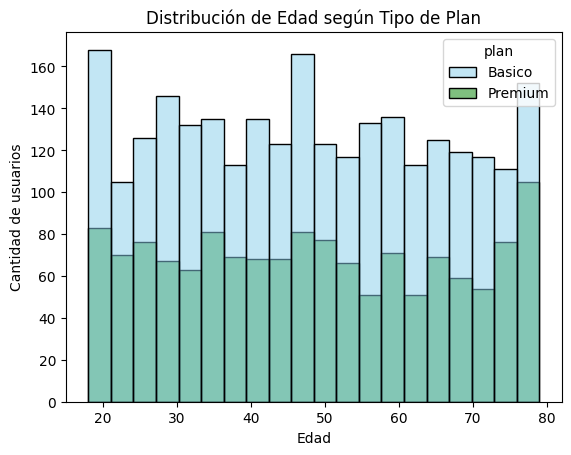

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"]
)

plt.title("Distribución de Edad según Tipo de Plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")

plt.show()

💡### Insight:

La distribución de edad de los usuarios muestra cómo se concentran los clientes según el tipo de plan contratado. Se observa que ambos planes presentan rangos de edad similares, por lo que no existe una diferencia marcada entre usuarios Básico y Premium respecto a esta variable.

La variable `age` presenta una distribución aproximadamente simétrica, aunque puede existir una ligera concentración en ciertos rangos de edad. Esto indica que la edad no parece ser el principal factor diferenciador para la elección del plan.

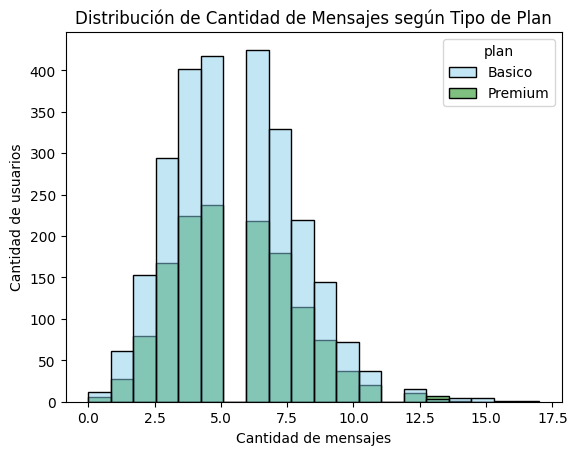

In [34]:
# Histograma para visualizar la cantidad de mensajes (cant_mensajes)
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"]
)

plt.title("Distribución de Cantidad de Mensajes según Tipo de Plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")

plt.show()


### Insight:

La distribución de `cant_mensajes` muestra una concentración de usuarios con un consumo bajo o moderado de mensajes y una menor cantidad de usuarios con valores altos de uso, lo que indica una distribución sesgada hacia la derecha.

Al comparar por tipo de plan, los usuarios Premium presentan una tendencia a un mayor volumen de mensajes frente a los usuarios Básico, aunque existe una amplia variabilidad dentro de ambos grupos. Esto sugiere que el tipo de plan puede influir en el nivel de consumo, pero no es el único factor que determina el comportamiento del usuario.

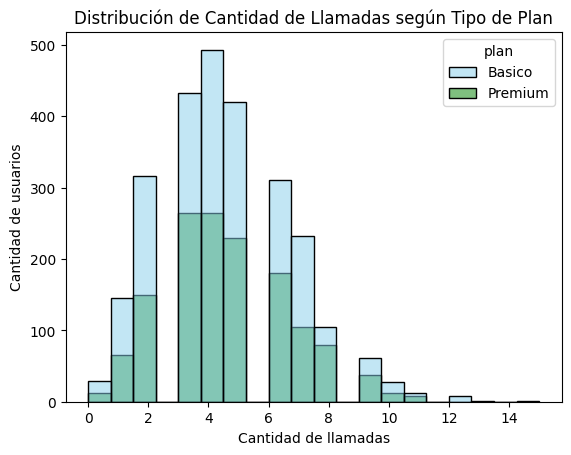

In [35]:
# Histograma para visualizar la cantidad de llamadas (cant_llamadas)
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"]
)

plt.title("Distribución de Cantidad de Llamadas según Tipo de Plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")

plt.show()



### Insight:

La distribución de `cant_llamadas` muestra que la mayoría de usuarios realiza una cantidad moderada de llamadas, mientras que pocos usuarios presentan volúmenes de llamadas significativamente altos, generando una distribución sesgada hacia la derecha.

Al comparar los planes, se observa si los usuarios Premium tienen una mayor frecuencia de llamadas frente a los usuarios Básico. Si ambas distribuciones presentan un comportamiento similar, el tipo de plan no parece ser un factor determinante para la cantidad de llamadas realizadas.

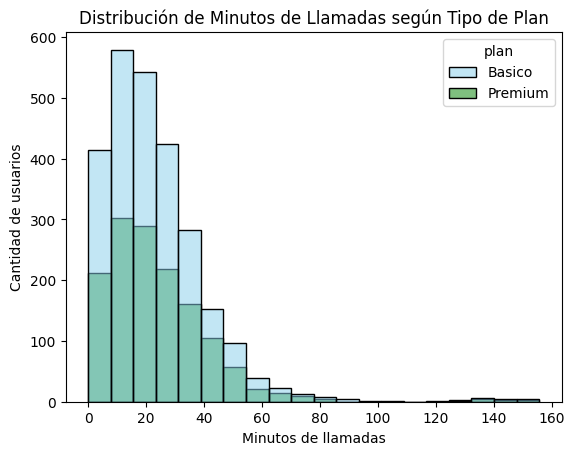

In [36]:
# Histograma para visualizar los minutos de llamadas (cant_minutos_llamada)
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"]
)

plt.title("Distribución de Minutos de Llamadas según Tipo de Plan")
plt.xlabel("Minutos de llamadas")
plt.ylabel("Cantidad de usuarios")

plt.show()


### Insight:

La distribución de `cant_minutos_llamada` presenta un sesgo hacia la derecha, donde la mayoría de usuarios acumula un consumo moderado de minutos, mientras que un grupo reducido concentra valores elevados de uso.

Al comparar los planes, los usuarios Premium pueden presentar una mayor concentración de minutos consumidos debido a los beneficios incluidos en su plan. Sin embargo, se recomienda revisar valores extremos para identificar usuarios con comportamientos atípicos o necesidades específicas de consumo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

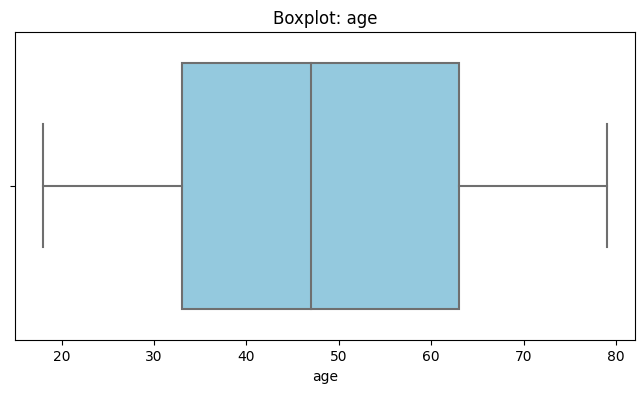

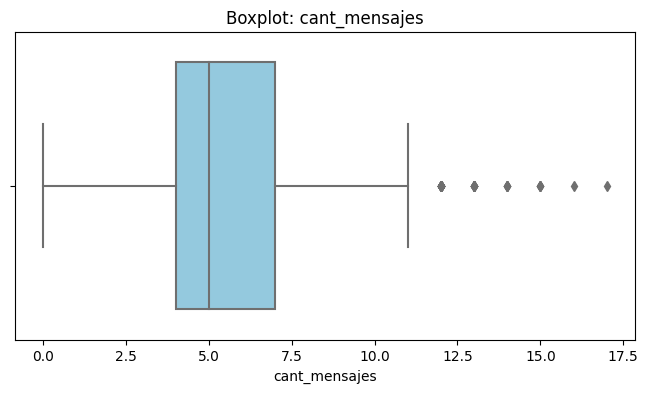

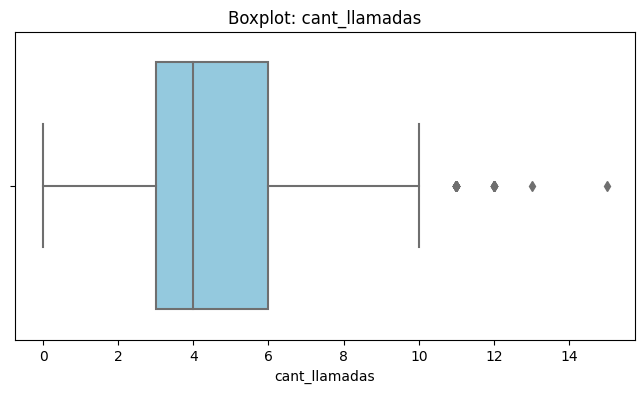

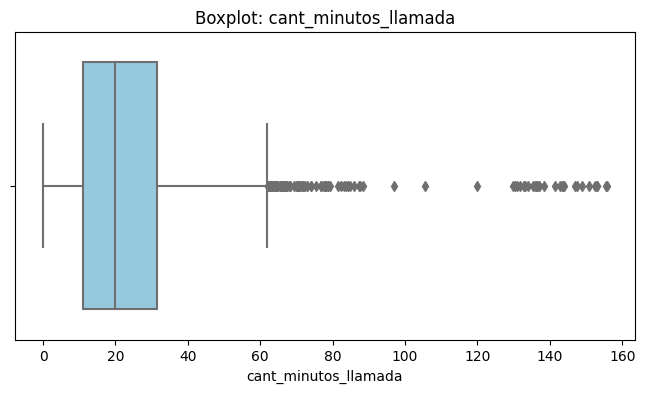

In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=user_profile, x=col, color="skyblue")
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()


### Insights:

**Age:**  
La variable `age` no presenta una cantidad significativa de outliers. Los valores se encuentran dentro de un rango esperado de edades de clientes, por lo que no se evidencian problemas de calidad en esta variable.

**cant_mensajes:**  
La variable `cant_mensajes` presenta algunos valores atípicos hacia valores altos. Estos representan usuarios con un consumo de mensajes superior al comportamiento habitual, posiblemente clientes con mayor interacción o uso intensivo del servicio.

**cant_llamadas:**  
La variable `cant_llamadas` presenta outliers superiores, asociados a usuarios que realizan una cantidad de llamadas mayor al promedio. Estos casos deben revisarse para determinar si corresponden a clientes de alto consumo o comportamientos inusuales.

**cant_minutos_llamada:**  
La variable `cant_minutos_llamada` presenta valores extremos hacia la derecha, indicando usuarios con un consumo elevado de minutos. Estos valores no necesariamente son errores, ya que pueden representar clientes con necesidades de comunicación más altas.

In [38]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    print(col)
    print("Límite inferior:", limite_inferior)
    print("Límite superior:", limite_superior)
    print()



cant_mensajes
Límite inferior: -0.5
Límite superior: 11.5

cant_llamadas
Límite inferior: -1.5
Límite superior: 10.5

cant_minutos_llamada
Límite inferior: -19.322500000000005
Límite superior: 61.8575



In [39]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


### Insights:

**cant_mensajes:**  
Se recomienda **mantener los outliers**, ya que los valores elevados pueden representar usuarios con un uso intensivo del servicio de mensajería. Estos clientes pueden ser un segmento importante para estrategias comerciales y no necesariamente corresponden a errores en los datos.

**cant_llamadas:**  
Se recomienda **mantener los outliers**, debido a que una alta cantidad de llamadas puede reflejar clientes con necesidades de comunicación superiores o usuarios empresariales. Antes de eliminarlos, deben revisarse para confirmar que correspondan a comportamientos reales.

**cant_minutos_llamada:**  
Se recomienda **mantener los outliers**, porque los valores extremos pueden representar usuarios con alto consumo de minutos y aportar información relevante para diseñar planes personalizados. No se consideran errores automáticamente, sino posibles segmentos de alto valor para la compañía.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
Buen trabajo con las visualizaciones y la revisión de outliers. Incluyes histogramas por plan, boxplots y cálculo de límites IQR para las variables principales de uso. También justificas adecuadamente por qué los valores extremos pueden conservarse como comportamientos reales de clientes intensivos, no necesariamente como errores.
</div>


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [41]:
# Crear columna grupo_uso
import numpy as np

user_profile["grupo_uso"] = np.where(
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    "Bajo uso",
    np.where(
        (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10),
        "Uso medio",
        "Alto uso"
    )
)

# Verificar resultados
user_profile["grupo_uso"].value_counts()


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [43]:
# Crear columna grupo_edad
# Crear columna grupo_edad
user_profile["grupo_edad"] = np.where(
    user_profile["age"] < 30,
    "Joven",
    np.where(
        user_profile["age"] < 60,
        "Adulto",
        "Adulto Mayor"
    )
)

# Verificar resultados
user_profile["grupo_edad"].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

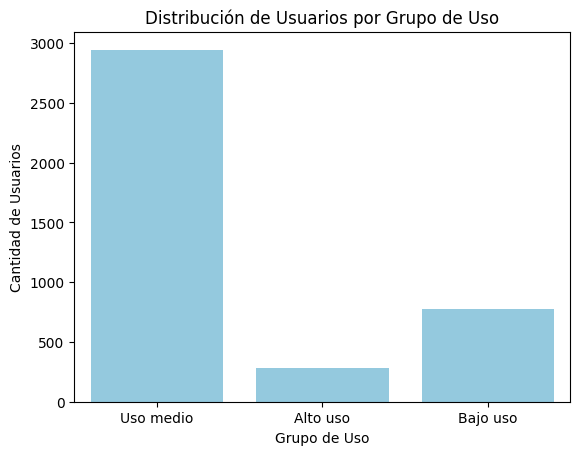

In [46]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x="grupo_uso",
    color="skyblue"
)

plt.title("Distribución de Usuarios por Grupo de Uso")
plt.xlabel("Grupo de Uso")
plt.ylabel("Cantidad de Usuarios")

plt.show()

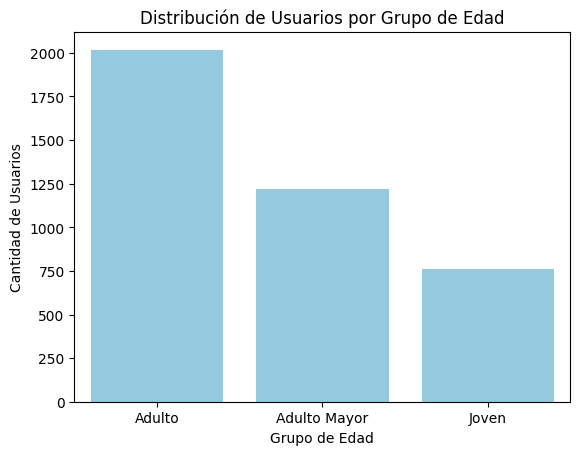

In [47]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x="grupo_edad",
    color="skyblue"
)

plt.title("Distribución de Usuarios por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")

plt.show()


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
La segmentación cumple con el objetivo del paso. Creas correctamente los grupos de uso y edad, verificas la distribución de cada grupo y generas visualizaciones claras para comunicar la composición de los segmentos.
</div>



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

## 8.1. Análisis ejecutivo

### ⚠️ Problemas detectados en los datos

- Se identificaron valores inválidos en la columna `age`, donde existían registros con el valor sentinel `-999`. Estos datos fueron reemplazados utilizando la mediana para conservar la distribución de edades.
- En la variable `city` se encontraron valores `"?"`, los cuales fueron transformados a valores nulos para evitar inconsistencias en el análisis.
- Se revisaron las fechas de registro y uso, detectando posibles valores fuera del rango esperado. Estos registros fueron marcados como nulos.
- Las variables `duration` y `length` presentaron valores faltantes asociados al tipo de servicio, por lo que se conservaron al considerarse valores MAR.

---

### 🔍 Segmentos por Edad

Se identificaron tres grupos de clientes según su edad:

- **Joven:** usuarios menores de 30 años.
- **Adulto:** usuarios entre 30 y 59 años.
- **Adulto Mayor:** usuarios de 60 años o más.

La segmentación permite observar diferencias en comportamiento y diseñar estrategias comerciales adaptadas a las necesidades de cada grupo. Los usuarios jóvenes pueden estar más orientados a servicios digitales, mientras que los adultos pueden representar clientes con necesidades de comunicación más constantes.

---

### 📊 Segmentos por Nivel de Uso

Los clientes fueron clasificados según su consumo de llamadas y mensajes:

- **Bajo uso:** usuarios con poca interacción con los servicios.
- **Uso medio:** usuarios con consumo moderado.
- **Alto uso:** usuarios con mayor cantidad de llamadas y mensajes.

Los usuarios de alto uso representan una oportunidad comercial importante, ya que tienen mayor demanda del servicio y pueden estar interesados en planes con mayores beneficios.

➡️ Esto sugiere que ConnectaTel puede mejorar la personalización de sus planes utilizando segmentaciones basadas en edad y comportamiento de consumo, en lugar de ofrecer una única propuesta para todos los clientes.

---

### 💡 Recomendaciones

- Crear planes diferenciados según el nivel de consumo:
  - Plan básico para usuarios de bajo uso.
  - Plan intermedio para usuarios de consumo moderado.
  - Plan premium o personalizado para usuarios de alto consumo.

- Diseñar campañas específicas por edad y comportamiento:
  - Ofertas digitales para usuarios jóvenes.
  - Beneficios de fidelización para adultos con alto consumo.

- Mantener monitoreo de usuarios con consumos extremos (outliers), ya que pueden representar clientes de alto valor o necesidades especiales.

- Usar los datos de comportamiento real para ajustar beneficios de los planes actuales y mejorar la satisfacción del cliente.

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
El insight ejecutivo está bien estructurado y conecta problemas de calidad, segmentos y recomendaciones de negocio. Para fortalecerlo, agrega evidencia numérica concreta, por ejemplo: qué grupo de uso es el más frecuente, qué grupo de edad predomina o qué variables presentan outliers. Eso hará que las recomendaciones estén más respaldadas por los resultados del análisis.
</div>


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [49]:
## https://github.com/JeanNicolas-Conecta/sprint7-final-project.git

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
El repositorio de GitHub contiene el notebook, pero falta el archivo <code>README.md</code>. Este punto es obligatorio para la entrega. Agrega un README que incluya objetivo del proyecto, datasets utilizados, etapas del análisis, instrucciones para ejecutar el notebook y una breve síntesis de hallazgos. Además, reemplaza el placeholder <code>LINK a tu repo aquí</code> por el enlace real en una celda Markdown.
</div>
